In [1]:
!source-extractor -d > default.sex

In [2]:
!source-extractor -dp > default.param

In [3]:
%%writefile default.conv
CONV NORM
# 3x3 gaussian filter
1 2 1
2 4 2
1 2 1

Writing default.conv


In [6]:
%%writefile default.param
NUMBER
X_IMAGE
Y_IMAGE
ALPHA_J2000
DELTA_J2000
FLUX_AUTO
FLUXERR_AUTO
MAG_AUTO
MAGERR_AUTO
FLAGS

Overwriting default.param


In [3]:
!source-extractor abell.fits -c default.sex


> WARNING: This executable has been compiled using a version of the ATLAS library without support for multithreading. Performance will be degraded.

> 
----- Source Extractor 2.28.2 started on 2026-08-29 at 00:28:48 with 4 threads

> Setting catalog parameters
> Reading detection filter
> Initializing catalog
> Looking for abell.fits
----- Measuring from: abell.fits [1/5]
      "Unnamed" / no ext. header / 5738x5675 / 32 bits (floats)
Detection+Measurement image: > Setting up background maps
> Setting up background map at line:   64
> Setting up background map at line:  128
> Setting up background map at line:  192
> Setting up background map at line:  256
> Setting up background map at line:  320
> Setting up background map at line:  384
> Setting up background map at line:  448
> Setting up background map at line:  512
> Setting up background map at line:  576
> Setting up background map at line:  640
> Setting up background map at line:  704
> Setting up background map at line:  76

1. `!source-extractor -d > default.sex` = Gerar o arquivo de configuração padrão (default.sex); comando para criar o arquivo de configuração base na pasta
2. `!source-extractor -dp > default.param` = Gerar os arquivos de catálogo de parâmetros e convolução; O SExtractor precisa de um arquivo com a lista de parâmetros desejados (default.param) e um filtro (default.conv)
3. `%%writefile default.conv` = arquivo de filtro de convolução básico
4. `%%writefile default.param` = definir o que o SExtractor deve medir (coordenadas, fluxo e magnitude)
5. `!source-extractor abell.fits -c default.sex` = executar a extração de fontes no arquivo FITS; Com os arquivos de configuração criados no mesmo diretório, execute a extração da imagem fits

In [4]:
from astropy.io import fits, ascii
from astropy.visualization import ZScaleInterval
from astropy.stats import sigma_clipped_stats
from photutils.aperture import CircularAperture
from photutils.detection import DAOStarFinder
from photutils.segmentation import detect_threshold, detect_sources, deblend_sources, SourceCatalog

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
# pra ler a tabela test.cat gerada pelo SE

cat = ascii.read('test.cat')
cat.to_pandas().head()

,NUMBER,X_IMAGE,Y_IMAGE,ALPHA_J2000,DELTA_J2000,FLUX_AUTO,FLUXERR_AUTO,MAG_AUTO,MAGERR_AUTO,FLAGS
0,1,2214.5178,436.6549,197.883595,-1.373237,30.192890,0.403532,-3.6998,0.0145,3
1,2,2224.1025,657.9860,197.883462,-1.370163,562.618000,0.289204,-6.8755,0.0006,0
2,3,1905.1914,1003.4846,197.887892,-1.365365,242.763700,0.714786,-5.9630,0.0032,18
3,4,2075.8906,379.0813,197.885521,-1.374037,5.120359,0.221618,-1.7733,0.0470,3
4,5,1950.0021,261.7498,197.887270,-1.375667,27.177850,0.292936,-3.5855,0.0117,0


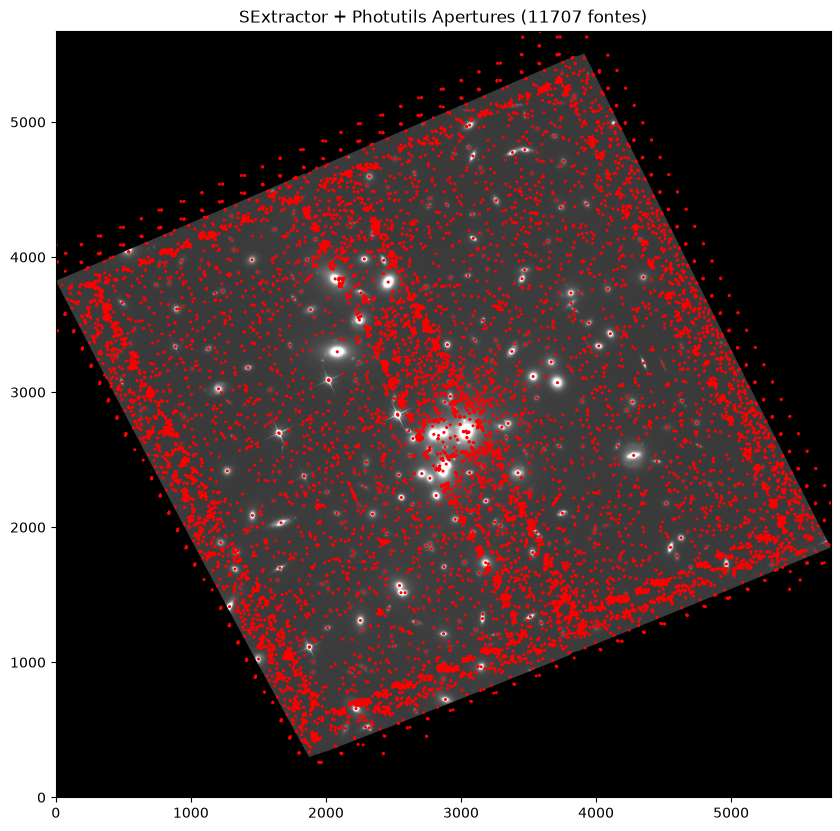

In [6]:
data = fits.getdata('abell.fits') #carregar image
cat = ascii.read('test.cat') #carregar a tabela de fontes gerada pelo SE

positions = list(zip(cat['X_IMAGE']-1, cat['Y_IMAGE']-1)) #pega posições X,Y geradas SE
# subtrai 1 pk o SE começa em 1 e o Python em 0

apertures = CircularAperture(positions, r=5.0) #as aberturas

zscale = ZScaleInterval()
vmin, vmax = zscale.get_limits(data) #esses dois eh pra ajustar o constraste da imagem

plt.figure(figsize=(10, 10))
plt.imshow(data, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
apertures.plot(color='red', lw=1.2)
plt.title(f'SExtractor + Photutils Apertures ({len(cat)} fontes)')
plt.show()

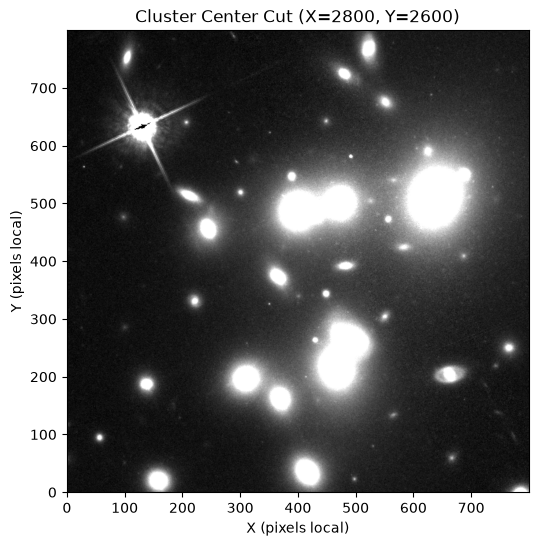

In [7]:
#coordenadas baseadas na imagem acima
center_x = 2800
center_y = 2600

#tamanho ne
box_size = 800
half_box = box_size // 2

#corte [linhas Y, colunas X]
crop_data = data[center_y - half_box : center_y + half_box,
                 center_x - half_box : center_x + half_box]

#ver o resultado
zscale = ZScaleInterval()
vmin, vmax = zscale.get_limits(crop_data)

plt.figure(figsize=(6, 6))
plt.imshow(crop_data, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
plt.title(f'Cluster Center Cut (X={center_x}, Y={center_y})')
plt.xlabel('X (pixels local)')
plt.ylabel('Y (pixels local)')
plt.show()

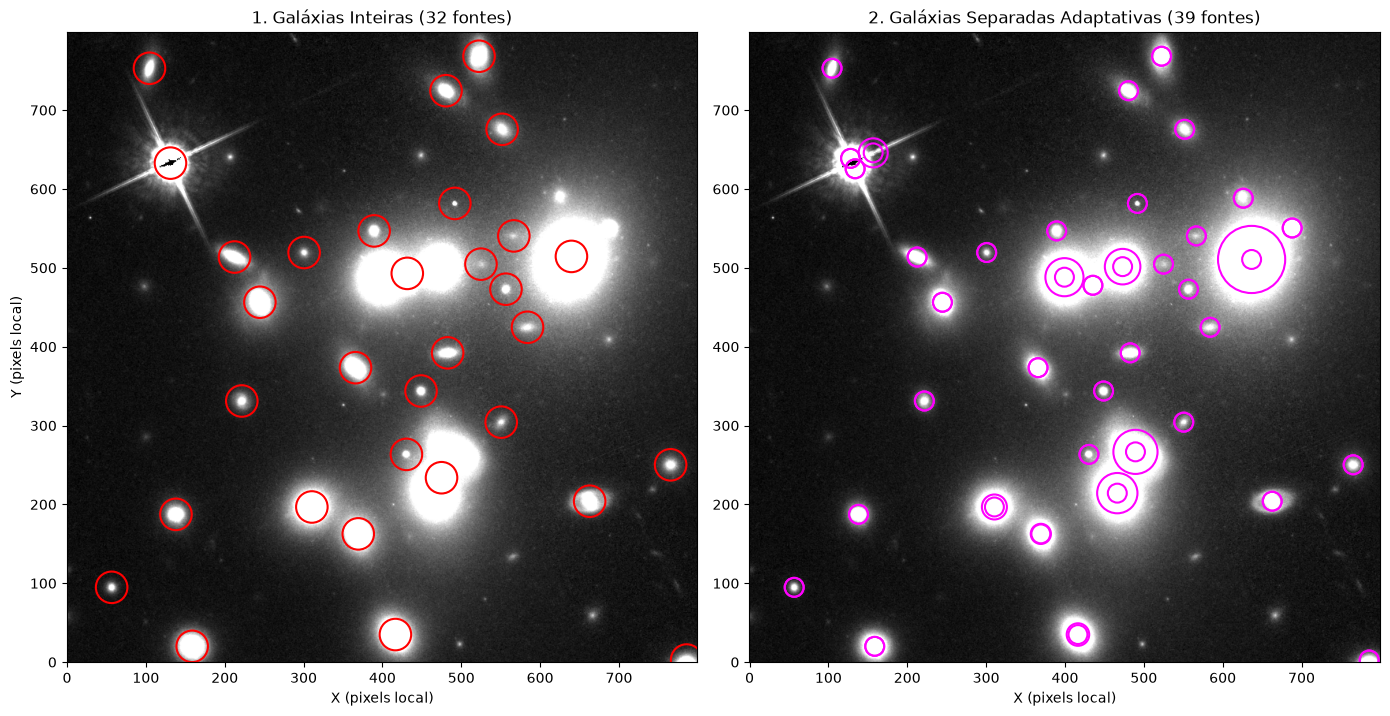

In [19]:
#usar photutils pros circulos

mean, median, std = sigma_clipped_stats(crop_data, sigma=3.0)
threshold = detect_threshold(crop_data, nsigma=2.5)

#detectar os alvos
segment_map = detect_sources(crop_data - median, threshold, npixels=15)

cat_fase1 = SourceCatalog(crop_data - median, segment_map)
pos_fase1 = list(zip(cat_fase1.xcentroid, cat_fase1.ycentroid))
apertures_fase1 = CircularAperture(pos_fase1, r=20)

#deblend
segm_deblended = deblend_sources(
    crop_data - median, 
    segment_map, 
    npixels=10, 
    nlevels=32, 
    contrast=0.005 #ajuste de sensibilidade para a separação
)

if segm_deblended is None:
    segm_deblended = segment_map

cat_fase2 = SourceCatalog(crop_data - median, segm_deblended)
pos_fase2 = list(zip(cat_fase2.xcentroid, cat_fase2.ycentroid))
apertures_fase2 = CircularAperture(pos_fase2, r=12)

#vizualização lado a lado
zscale = ZScaleInterval()
vmin, vmax = zscale.get_limits(crop_data)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

#grafico 01
ax1.imshow(crop_data, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
apertures_fase1.plot(ax=ax1, color='red', lw=1.5)
ax1.set_title(f'1. Galáxias Inteiras ({len(cat_fase1)} fontes)')
ax1.set_xlabel('X (pixels local)')
ax1.set_ylabel('Y (pixels local)')

#grafico 02
ax2.imshow(crop_data, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
apertures_fase2.plot(ax=ax2, color='magenta', lw=1.5)
ax2.set_title(f'2. Galáxias Separadas Adaptativas ({len(cat_fase2)} fontes)')
ax2.set_xlabel('X (pixels local)')

#desenhar circulo individual pra cada galaxia, baseada no tamanho
    #SO pra ficar mais bonitinho
for obj in cat_fase2:
    r_adaptativo = max(12, obj.semimajor_sigma.value * 1.5)

    ap = CircularAperture((obj.x_centroid, obj.y_centroid), r=r_adaptativo)
    ap.plot(ax=ax2, color='magenta', lw=1.5)
 
#plot
plt.tight_layout()
plt.savefig('abell_clusters_deblend.png', dpi=300, bbox_inches='tight')
plt.show()